# ECMWF Project

## About ECMWF: European Centre for Medium-Range Weather Forecasts

## Overview

The **European Centre for Medium-Range Weather Forecasts (ECMWF)** is an independent intergovernmental organization supported by 35 European countries. Founded in 1975, it is one of the world’s leading centers for global numerical weather prediction and atmospheric research.

ECMWF is known for:
- Producing some of the **most accurate global weather forecasts**.
- Operating powerful supercomputers for data assimilation and simulation.
- Providing essential data to national meteorological services, researchers, and institutions.

**Official website**: [https://www.ecmwf.int](https://www.ecmwf.int)


## Mission and Purpose

> *“To produce global numerical weather forecasts and conduct scientific and technical research to improve forecasting.”*

ECMWF supports:
- **Medium-range weather forecasting** (up to 15 days)
- **Sub-seasonal and seasonal forecasting**
- **Reanalysis datasets** (e.g., ERA5)
- **Climate monitoring and atmospheric composition**
- **Severe weather support and emergency response**


## Types of Forecast Products

### A. **High-Resolution Forecasts (HRES)**
- Single deterministic forecasts
- 9 km horizontal resolution
- 15-day forecasts updated twice daily
- Atmospheric variables: pressure, temperature, precipitation, wind, humidity, etc.

### B. **Ensemble Forecasts (ENS)**
- 51-member forecast ensemble
- Measures forecast uncertainty
- Used for probabilistic prediction up to 46 days

### C. **Ocean Wave Model Forecasts (WAM)**
- Simulations of **wave height**, **direction**, and **period**
- Coupled to atmospheric model
- HRES-WAM: deterministic, high-resolution ocean wave forecast
- ENS-WAM: ensemble wave forecast

### D. **Seasonal Forecasts (SEAS)**
- Climate-scale predictions up to 7 months ahead
- Useful for agriculture, energy, and water management


## Data Access and Formats

### 1. **Copernicus Climate Data Store (CDS)**
Access to:
- ERA5 reanalysis data
- Climate indicators
- Forecasts and satellite-derived datasets

[Copernicus Climate Data Store](https://cds.climate.copernicus.eu/)

Requires:
- Free user registration
- Python client: `cdsapi`

### 2. **ECMWF Open Data Portal**
Provides open access to a subset of HRES forecast data.

[https://www.ecmwf.int/en/forecasts/datasets/open-data](https://www.ecmwf.int/en/forecasts/datasets/open-data)

No login or API key required.

### 3. **Real-time License Access**
For licensed users (e.g., national weather services, academic institutions), ECMWF provides full access to real-time operational forecasts.

🔗 [Real-Time Data Catalogue](https://www.ecmwf.int/en/forecasts/datasets/catalogue-ecmwf-real-time-products)


## Data Formats

ECMWF data comes in two main formats:
- **GRIB** (GRIdded Binary): compact, efficient format for meteorological fields.
  - Used for operational forecasts
  - Readable with tools like `cfgrib`, `eccodes`, `metview`
- **NetCDF**: common in climate and oceanography.
  - Used mostly in reanalysis products like ERA5


## Tools and Libraries

| Tool / Library     | Purpose                                     | Link |
|--------------------|---------------------------------------------|------|
| `cdsapi`           | Python client for Copernicus API            | [GitHub](https://github.com/ecmwf/cdsapi) |
| `ecmwf-opendata`   | Python access to ECMWF open forecasts       | [GitHub](https://github.com/ecmwf/ecmwf-opendata) |
| `metview`          | Meteorological analysis and visualization   | [Metview](https://confluence.ecmwf.int/display/METV/Metview) |
| `cfgrib`           | Interface for reading GRIB files with xarray| [cfgrib](https://github.com/ecmwf/cfgrib) |
| `eccodes`          | C library + Python bindings for GRIB/BUFR   | [ecCodes](https://confluence.ecmwf.int/display/ECC/ecCodes+Home) |



## Example Variables You Can Retrieve

### Atmosphere:
- `2t`: 2m temperature
- `u10`, `v10`: 10m wind components
- `msl`: mean sea level pressure
- `tcc`: total cloud cover

### Ocean / Wave:
- `swh`: Significant wave height
- `mwd`: Mean wave direction
- `pp1d`: Peak wave period


## How to Get Started with ECMWF Data

### Step 1: Register for Copernicus
- Go to [https://cds.climate.copernicus.eu/](https://cds.climate.copernicus.eu/)
- Create an account and accept license terms

### Step 2: Install the API client


In [3]:
!pip install cdsapi cfgrib xarray netCDF4 cartopy matplotlib plotly --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 422.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.9 MB/s eta 0:00:00


In [4]:
import os

# 🔐 Pega tu clave entre las comillas triples
cdsapirc = """
url: https://cds.climate.copernicus.eu/api
key: 697a15cd-dedc-492d-8df6-80d489fb8bcf
"""

# Guardar el archivo de configuración
with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(cdsapirc.strip())

### Step 3: Download Wave + Wind Data (ERA5)
This example downloads:

- significant_height_of_combined_wind_waves_and_swell (wave height)

- 10m_u_component_of_wind, 10m_v_component_of_wind (wind components)

For:

- Date: July 1, 2024

- Time: 12:00 UTC

- Region: Western Europe Atlantic Coast [60N, -30W, 30N, 30E]


In [7]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "data_format": "grib",
    "download_format": "unarchived"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2025-07-15 17:06:36,013 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


HTTPError: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5-single-levels/execution
invalid request
None of the data you have requested is available yet, please revise the period requested. The latest date available for this dataset is: 2025-07-10 17:00

In [8]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
            'significant_height_of_combined_wind_waves_and_swell'
        ],
        'year': '2024',
        'month': '07',
        'day': '01',
        'time': ['12:00'],
        'area': [60, -30, 30, 30],  # [North, West, South, East]
    },
    'era5_wind_wave.nc'
)


2025-07-15 17:07:00,322 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-15 17:07:03,408 INFO Request ID is c071f9f0-b507-4c02-9b30-43830e94b303
INFO:ecmwf.datastores.legacy_client:Request ID is c071f9f0-b507-4c02-9b30-43830e94b303
2025-07-15 17:07:03,652 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-07-15 17:07:13,068 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e39cf2328f7a30e677627ee3495e3244.zip:   0%|          | 0.00/195k [00:00<?, ?B/s]

'era5_wind_wave.nc'

### Step 4: Read and Visualize Data with xarray

In [17]:
import zipfile
import os

zip_file_path = "era5_wind_wave.nc"
extracted_dir = "./extracted_data"

if zipfile.is_zipfile(zip_file_path):
    print(f"Extracting '{zip_file_path}' to '{extracted_dir}'...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_dir)
    print("Extraction complete.")
else:
    print(f"'{zip_file_path}' is not a zip file. Skipping extraction.")

# Find the extracted .nc file
extracted_nc_file = None
if os.path.exists(extracted_dir):
    for filename in os.listdir(extracted_dir):
        if filename.endswith(".nc"):
            extracted_nc_file = os.path.join(extracted_dir, filename)
            print(f"Found extracted NetCDF file: '{extracted_nc_file}'")
            break

if extracted_nc_file is None:
    print("No .nc file found in the extracted directory.")

Extracting 'era5_wind_wave.nc' to './extracted_data'...
Extraction complete.
Found extracted NetCDF file: './extracted_data/data_stream-wave_stepType-instant.nc'


### Step 5: Open and explore the NetCDF file

In [18]:
import xarray as xr

# Load the dataset (from extracted location)
ds = xr.open_dataset(extracted_nc_file)

# Print basic info
print(ds)


<xarray.Dataset> Size: 31kB
Dimensions:     (valid_time: 1, latitude: 61, longitude: 121)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2024-07-01T12:00:00
  * latitude    (latitude) float64 488B 60.0 59.5 59.0 58.5 ... 31.0 30.5 30.0
  * longitude   (longitude) float64 968B -30.0 -29.5 -29.0 ... 29.0 29.5 30.0
    expver      <U4 16B ...
Data variables:
    swh         (valid_time, latitude, longitude) float32 30kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-15T17:06 GRIB to CDM+CF via cfgrib-0.9.1...


### Step 6: Plot Significant Wave Height (SWH)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


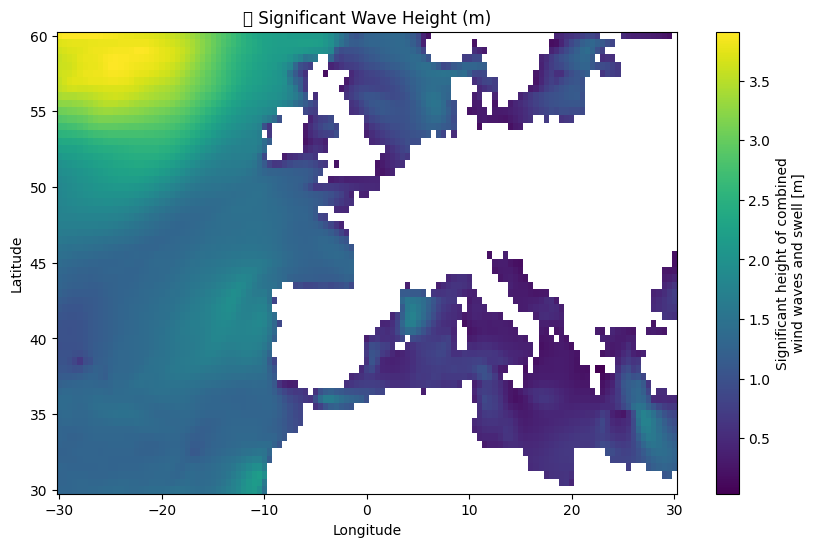

In [21]:
import matplotlib.pyplot as plt

swh = ds['swh'].isel(valid_time=0)

plt.figure(figsize=(10,6))
swh.plot(cmap="viridis")
plt.title("🌊 Significant Wave Height (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [23]:
u10 = ds['u10'].isel(valid_time=0)
v10 = ds['v10'].isel(valid_time=0)

# Downsample for readability
u_plot = u10[::5, ::5]
v_plot = v10[::5, ::5]
lon = u_plot.longitude
lat = u_plot.latitude

plt.figure(figsize=(12, 7))
plt.quiver(lon, lat, u_plot, v_plot, scale=700)
plt.title("🌬️ 10m Wind Vectors (u10/v10)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


KeyError: "No variable named 'u10'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'swh']"

In [26]:
import nbformat
from google.colab import files
import json

# Obtener el notebook actual desde el entorno de ejecución (usamos IPython para inferir nombre)
import os
import IPython

# Paso 1: Guardar el notebook actual en disco temporal
notebook_name = "colab_notebook_cleaned.ipynb"

# Crear un notebook limpio desde cero, copiando celdas activas
nb = nbformat.v4.new_notebook()
nb['cells'] = []

# Recolectar todas las celdas actuales del entorno
for cell in IPython.get_ipython().user_ns['_ih']:
    if cell.strip():
        nb['cells'].append(nbformat.v4.new_code_cell(source=cell.strip()))

# Eliminar widgets si existen
if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']

# Guardar notebook limpio
with open(notebook_name, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

# Descargar notebook corregido
files.download(notebook_name)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>